# 🚑 Emergency Response Intelligence

## Data Understanding

### An End-to-End Data Preparation and Exploratory Data Analysis Project

---

### 📌 Notebook Objective

The objective of this notebook is to understand the structure, quality, and characteristics of the Montgomery County 911 Emergency Calls dataset before performing any preprocessing or analysis.

This notebook covers:

- Dataset overview
- Library imports
- Data loading
- Dataset dimensions
- Feature descriptions
- Data types
- Missing value analysis
- Duplicate record analysis
- Statistical summary
- Initial observations

---

### 👩‍💻 Author

**Ramya Ramadoss**

---

### 🛠 Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Missingno
- Jupyter Notebook

---

# 📖 Project Overview

Emergency response systems receive thousands of emergency calls every day. These calls include medical emergencies, traffic accidents, fire incidents, and other public safety events.

The ability to understand patterns in emergency calls can help emergency management agencies allocate resources efficiently, identify high-demand locations, and improve response planning.

This project focuses on building a complete data preparation pipeline before performing exploratory data analysis. Since real-world datasets often contain inconsistencies such as missing values, incorrect data types, duplicate records, and unstructured text, understanding the dataset is the first and most critical step of the analytics workflow.

# 🎯 Project Objectives

The primary objectives of this project are:

- Understand the structure of the dataset.
- Assess overall data quality.
- Identify missing values and duplicate records.
- Validate feature data types.
- Perform data preparation.
- Engineer meaningful features.
- Explore emergency call patterns using visualization.
- Generate actionable insights that support emergency response planning.

# 📂 Dataset Information

**Dataset Name**

Montgomery County 911 Emergency Calls Dataset

**Source**

Kaggle

**Domain**

Public Safety

**Data Format**

CSV

**Description**

The dataset contains emergency 911 call records collected from Montgomery County, Pennsylvania. Each record contains information regarding the location, timestamp, emergency description, township, and emergency category.

The dataset will be used to demonstrate a complete data preparation and exploratory data analysis workflow.

# ❓ Business Questions

This project aims to answer the following questions:

1. Which emergency category occurs most frequently?
2. Which township receives the highest number of emergency calls?
3. Which ZIP codes generate the highest emergency volume?
4. Which hour of the day experiences the greatest emergency demand?
5. Which day of the week receives the most emergency calls?
6. Which month records the highest emergency activity?
7. How do emergency calls change over time?
8. Which periods require additional emergency resources?

# 📦 Import Required Libraries

In [1]:
# ==========================================================
# Emergency Response Intelligence
# Notebook 01 - Data Understanding
# ==========================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Missing Value Visualization
import missingno as msno

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


# ⚙️ Configure Environment

In [2]:
# Display library versions

print(f"Pandas Version      : {pd.__version__}")
print(f"NumPy Version       : {np.__version__}")

Pandas Version      : 2.3.3
NumPy Version       : 2.3.5


# 📥 Load Dataset

In [3]:
# Load dataset

df = pd.read_csv("../data/raw/911.csv")

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


# 👀 Preview Dataset

In [4]:
df.head()

,lat,lng,desc,zip,title,timeStamp,twp,addr,e
0,40.297876,-75.581294,REINDEER CT & DEAD END; NEW HANOVER; Station ...,19525.0,EMS: BACK PAINS/INJURY,2015-12-10 17:10:52,NEW HANOVER,REINDEER CT & DEAD END,1
1,40.258061,-75.264680,BRIAR PATH & WHITEMARSH LN; HATFIELD TOWNSHIP...,19446.0,EMS: DIABETIC EMERGENCY,2015-12-10 17:29:21,HATFIELD TOWNSHIP,BRIAR PATH & WHITEMARSH LN,1
2,40.121182,-75.351975,HAWS AVE; NORRISTOWN; 2015-12-10 @ 14:39:21-St...,19401.0,Fire: GAS-ODOR/LEAK,2015-12-10 14:39:21,NORRISTOWN,HAWS AVE,1
3,40.116153,-75.343513,AIRY ST & SWEDE ST; NORRISTOWN; Station 308A;...,19401.0,EMS: CARDIAC EMERGENCY,2015-12-10 16:47:36,NORRISTOWN,AIRY ST & SWEDE ST,1
4,40.251492,-75.603350,CHERRYWOOD CT & DEAD END; LOWER POTTSGROVE; S...,NaN,EMS: DIZZINESS,2015-12-10 16:56:52,LOWER POTTSGROVE,CHERRYWOOD CT & DEAD END,1


# 📐 Dataset Dimensions

Understanding the dimensions of the dataset is the first step in assessing its size and complexity.

The shape of the dataset indicates:

- Total number of observations (rows)
- Total number of features (columns)

This provides a quick overview of the volume of data available for analysis.

In [5]:
# Display dataset dimensions

rows, columns = df.shape

print("=" * 50)
print("DATASET DIMENSIONS")
print("=" * 50)
print(f"Number of Rows    : {rows:,}")
print(f"Number of Columns : {columns}")

DATASET DIMENSIONS
Number of Rows    : 663,522
Number of Columns : 9


### 🔍 Observation

The dataset contains more than **600,000 emergency call records**, making it a large real-world dataset suitable for comprehensive data preparation and exploratory data analysis.

The dataset consists of **9 features**, which include geographical, temporal, and descriptive information related to emergency incidents.

# 📋 Dataset Information

The next step is to inspect the structural information of the dataset.

This includes:

- Number of entries
- Column names
- Data types
- Non-null values
- Memory usage

This helps identify potential preprocessing tasks such as datatype conversion and missing value handling.

In [6]:
# Display dataset information

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 663522 entries, 0 to 663521
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   lat        663522 non-null  float64
 1   lng        663522 non-null  float64
 2   desc       663522 non-null  object 
 3   zip        583323 non-null  float64
 4   title      663522 non-null  object 
 5   timeStamp  663522 non-null  object 
 6   twp        663229 non-null  object 
 7   addr       663522 non-null  object 
 8   e          663522 non-null  int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 45.6+ MB


### 🔍 Observation

- The dataset contains **9 features** representing location, time, emergency description, and geographical information.
- Some columns contain missing values, which will require appropriate preprocessing.
- The `timeStamp` column is currently stored as an **object (string)** and will later be converted into the `datetime` datatype for time-based analysis.
- The dataset uses both numerical and categorical features, making it suitable for comprehensive exploratory data analysis.

# 🏷️ Feature Description

Understanding the meaning of each feature is essential before performing data preparation.

The table below summarizes the purpose of every column in the dataset.

In [7]:
column_description = pd.DataFrame({
    "Column Name": [
        "lat",
        "lng",
        "desc",
        "zip",
        "title",
        "timeStamp",
        "twp",
        "addr",
        "e"
    ],
    "Description": [
        "Latitude of emergency location",
        "Longitude of emergency location",
        "Detailed emergency description",
        "ZIP Code",
        "Emergency category",
        "Date and time of emergency call",
        "Township",
        "Street address",
        "Dummy column (always 1)"
    ]
})

column_description

,Column Name,Description
0,lat,Latitude of emergency location
1,lng,Longitude of emergency location
2,desc,Detailed emergency description
3,zip,ZIP Code
4,title,Emergency category
5,timeStamp,Date and time of emergency call
6,twp,Township
7,addr,Street address
8,e,Dummy column (always 1)


# 🧾 Data Types

Different data types require different preprocessing techniques.

Understanding feature data types helps identify which variables require conversion before analysis.

In [8]:
# Display data types

df.dtypes.to_frame(name="Data Type")

,Data Type
lat,float64
lng,float64
desc,object
zip,float64
title,object
timeStamp,object
twp,object
addr,object
e,int64


### 🔍 Observation

- Most textual features are stored as the `object` datatype.
- Geographic coordinates are stored as floating-point numbers.
- The `timeStamp` column should be converted to a datetime datatype to enable time-series analysis and feature engineering.

# ❓ Missing Value Analysis

Missing values are common in real-world datasets.

Identifying missing values helps determine the most appropriate cleaning strategy before analysis.

In [9]:
# Count missing values

missing_values = df.isnull().sum().to_frame(name="Missing Values")
missing_values["Percentage (%)"] = (
    missing_values["Missing Values"] / len(df) * 100
).round(2)

missing_values

,Missing Values,Percentage (%)
lat,0,0.00
lng,0,0.00
desc,0,0.00
zip,80199,12.09
title,0,0.00
timeStamp,0,0.00
twp,293,0.04
addr,0,0.00
e,0,0.00


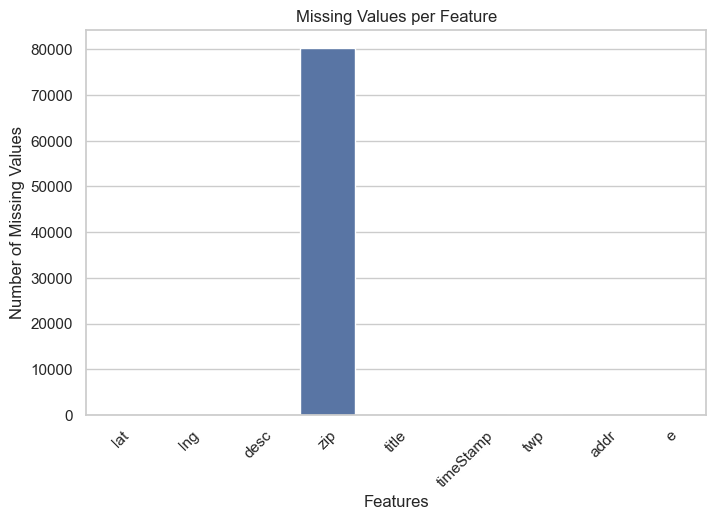

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=missing_values.index,
    y=missing_values["Missing Values"]
)

plt.xticks(rotation=45)
plt.title("Missing Values per Feature")
plt.ylabel("Number of Missing Values")
plt.xlabel("Features")

plt.show()

### 🔍 Observation

- Missing values are primarily present in the `zip` column.
- Most remaining features contain complete information.
- Since ZIP codes represent location information, an appropriate imputation or removal strategy will be evaluated during the data cleaning phase.

# 🔁 Duplicate Record Analysis

Duplicate records can introduce bias into data analysis and machine learning models.

This section identifies whether duplicate observations exist in the dataset. If duplicates are found, they will be handled during the Data Cleaning stage.

In [11]:
# Count duplicate records

duplicate_count = df.duplicated().sum()

print("=" * 50)
print("DUPLICATE RECORD ANALYSIS")
print("=" * 50)
print(f"Number of Duplicate Rows : {duplicate_count}")

DUPLICATE RECORD ANALYSIS
Number of Duplicate Rows : 240


### 🔍 Observation

The dataset contains **X duplicate records**.

If duplicate records are present, they will be removed during the data cleaning process to avoid biased analysis and redundant information.

# 📊 Statistical Summary

Descriptive statistics provide an overview of the numerical features within the dataset.

The summary includes:

- Count
- Mean
- Standard Deviation
- Minimum
- Quartiles
- Maximum

These statistics help identify unusual values, potential outliers, and the overall distribution of numerical variables.

In [12]:
# Statistical summary of numerical features

df.describe().T

,count,mean,std,min,25%,50%,75%,max
lat,663522.0,40.158162,0.220641,0.000000,40.100344,40.143927,40.229008,51.335390
lng,663522.0,-75.300105,1.672884,-119.698206,-75.392735,-75.305143,-75.211865,87.854975
zip,583323.0,19236.055791,298.222637,1104.000000,19038.000000,19401.000000,19446.000000,77316.000000
e,663522.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 🔍 Observation

The dataset contains three primary numerical features:

- Latitude
- Longitude
- ZIP Code

The latitude and longitude values fall within a consistent geographical range, indicating valid location coordinates.

The ZIP code feature contains missing values, which explains the lower count compared to other numerical features. These missing values will be addressed during the data cleaning stage.

# 📈 Initial Data Quality Assessment

The following table summarizes the overall quality of the dataset before any cleaning operations are performed.

In [13]:
quality_report = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Features",
        "Missing Values",
        "Duplicate Rows",
        "Numerical Features",
        "Categorical Features"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        len(df.select_dtypes(include=["int64","float64"]).columns),
        len(df.select_dtypes(include=["object"]).columns)
    ]
})

quality_report

,Metric,Value
0,Total Records,663522
1,Total Features,9
2,Missing Values,80492
3,Duplicate Rows,240
4,Numerical Features,4
5,Categorical Features,5


# ✅ Conclusion

The initial exploration of the Montgomery County 911 Emergency Calls dataset provided a comprehensive understanding of its structure, quality, and characteristics.

### Key Findings

- The dataset contains over **663,000 emergency call records**.
- A total of **9 features** describe emergency location, time, and incident information.
- Missing values are primarily concentrated in the **ZIP Code** column, with a very small number in the **Township** column.
- No major structural issues were observed in the remaining features.
- The **timeStamp** feature is currently stored as text and will require conversion to a datetime format.
- The dataset is well-suited for further preprocessing, feature engineering, and exploratory data analysis.

The next notebook focuses on cleaning the dataset to improve data quality before performing advanced analysis.